In [28]:
import os
import numexpr as ne
from langchain_core.tools import tool


# Calculator Tool
@tool
def calculator(expression: str):
    """Calculate a mathematical expression."""
    try:
        result = ne.evaluate(expression)
        return result.item()
    except Exception as e:
        return str(e)


# File Operation Tool
@tool
def file_handler(
    filename: str,
    operation: str,
    content: str = ""
):
    """
    Handles basic file operations such as create, read, append, and delete.
    """

    try:
        if operation == "read":

            with open(filename, "r") as file:
                return file.read()

        elif operation == "create":

            with open(filename, "w") as file:
                file.write(content)

            return f"File created: {filename}"

        elif operation == "append":

            with open(filename, "a") as file:
                file.write(content)

            return f"Content added to: {filename}"

        elif operation == "delete":

            if os.path.exists(filename):
                os.remove(filename)
                return f"File deleted: {filename}"

            return "File not found."

        else:
            return "Invalid operation."

    except Exception as e:
        return str(e)

# List of file return 
@tool
def list_files(path: str = "workspace"):
    """List all files and folders inside the given directory."""
    try:
        return os.listdir(path)
    except Exception as e:
        return str(e)
    
# terminal add 
import subprocess 
from langchain_core.tools import tool 

@tool 
def terminal(command:str):
    """Execute a terminal command inside the CodeFlow workspace.""" 
    try : 
        result = subprocess.run(
            command , 
            shell=True , 
            capture_output=True , 
            text=True , 
            cwd="workspace",
            timeout=30
        )
        
        return result.stdout if result.stdout else result.stderr
    except Exception as e:
        return str(e)

In [29]:
# LLM connction 
from langchain_groq import ChatGroq 
import os 
from dotenv import load_dotenv 
load_dotenv()
key = os.getenv('GROQ_API_KEY')
LLM = ChatGroq(model="openai/gpt-oss-120b",api_key=key)

LLM.invoke("hii ?").content

'Hey there! How can I help you today?'

In [ ]:
# LLM conection with the langGraph 
from langgraph.graph import START , StateGraph , END 
from langgraph.graph.message import add_messages , Annotated 
from typing import TypedDict 
tools = [calculator,file_handler,list_files,terminal]
# State create  
class state(TypedDict):
    messages : Annotated[list,add_messages]

# llm state contention  
tool_blind = LLM.bind_tools(tools=tools)

#tool connection 
def tool_connection(state:state):
    response = tool_blind.invoke(state['messages'])
    return {'messages':response}

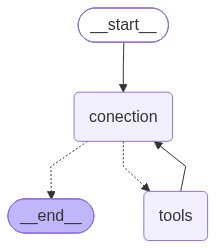

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

Builder = StateGraph(state)

Builder.add_node("conection", tool_connection)
Builder.add_node("tools", ToolNode(tools))

Builder.add_edge(START, "conection")

Builder.add_conditional_edges(
    "conection",
    tools_condition
)

Builder.add_edge("tools", "conection")

graph = Builder.compile()
graph

In [ ]:
from langchain_core.messages import HumanMessage
result = graph.invoke({
    "messages": [
        HumanMessage(
            content="Create workspace/file.txt containing: Hello CodeFlow"
        )
    ]
})

print(result)

{'messages': [HumanMessage(content='Create workspace/file.txt containing: Hello CodeFlow', additional_kwargs={}, response_metadata={}, id='609f850d-0759-429c-b313-ba5d549856db'), AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants to create a file at workspace/file.txt with content "Hello CodeFlow". Use file_handler with operation "create".', 'tool_calls': [{'id': 'fc_f9a9e450-d812-4a75-8fa2-4a53802438ea', 'function': {'arguments': '{"content":"Hello CodeFlow","filename":"workspace/file.txt","operation":"create"}', 'name': 'file_handler'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 199, 'total_tokens': 270, 'completion_time': 0.148625948, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.00851236, 'prompt_tokens_details': None, 'queue_time': 0.211947548, 'total_time': 0.157138308}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4a7bb72c24', 'service_tier': 'on_demand', '

In [ ]:
result = graph.invoke({
    "messages": [
        HumanMessage(
            content="List all files inside workspace"
        )
    ]
})

print(result["messages"][-1].content)

Here are the files currently in the workspace:

- `file.txt`
- `telegram.txt`


In [ ]:
result = graph.invoke({
    "messages": [
        HumanMessage(
            content="delete workspace/file.txt"
        )
    ]
})

print(result["messages"][-1].content)

The file `workspace/file.txt` has been deleted. Let me know if there’s anything else you’d like to do!


In [31]:
terminal.invoke("ls")

'file.txt\ntelegram.txt\n'

## DataBase 

In [1]:
from sqlalchemy import Integer , Column , create_engine ,String
from sqlalchemy.orm import DeclarativeBase , sessionmaker 

URL = "sqlite:///.SQL_DataBase.db"

# Create engine 
engine = create_engine(url=URL,connect_args={'check_same_thread':False})
#Session create 
session = sessionmaker(bind=engine,autoflush=False , autocommit=False)
#Base 
class Base(DeclarativeBase):
    pass

# Database create 
class SQL_base(Base):
    __tablename__="Database"
    user_id = Column(Integer , autoincrement=True , primary_key=True)
    question = Column(String)
    limit = Column(Integer)
    answer = Column(String)
Base.metadata.create_all(bind=engine)

# Create connections 
def create_db():
    db=session()
    try : 
        yield db
    finally:
        db.close()
    

## Aplication programing interface 

In [2]:
from fastapi import FastAPI , HTTPException , Depends 
from database import SQL_base , create_db
from agent import graph
from pydantic import BaseModel
from langchain_core.messages import HumanMessage 
from logger import logger

# Conection build 
app = FastAPI(title = "API_system")

# Data Define 
class API(BaseModel):
    question: str = None
    user_id: int = None
    id: int = None
    limit: int = 100
#put method    
@app.put("/ask")
def update(response:API , db=Depends(create_db)):
    question = db.query(SQL_base).filter(SQL_base.id==response.id).first()
    if not question:
        raise HTTPException(status_code=400 , detail="question doesnot find out")
    question.question = response.question
    db.commit()
    db.refresh(question)
    return {'updated':question}

#delete method
@app.delete("/ask")  
def delete_question(id : int , db=Depends(create_db)):
    question = db.query(SQL_base).filter(SQL_base.id==id).first() 
    if not question :
        raise HTTPException(status_code=400,detail="question not in database")
    delete = question.id 
    db.delete(question)
    db.commit()
    
    return {
        'status':'delete',
        'delete':delete
    }


#Get method     
@app.get("/ask")
def fetch(db=Depends(create_db)):
    try:
        question = db.query(SQL_base).all()
        return [{
            'id':q.id , 'answer':q.answer , 'question':q.question ,'user_id':q.user_id}
            for q in question
        ]
    except Exception as e :
        logger.error(f"Agent error: {e}")
        raise HTTPException(status_code=400 , detail=str(e))
    

import time 
# Post connection 
@app.post("/chat")
def asking(response:API , db=Depends(create_db)):
    
    logger.info("chat request recived")
    try:
        logger.info("Agent started")
        start = time.time()
        result = graph.invoke({
        'messages':[HumanMessage(content=(response.question))]
    })
        end = time.time()
        logger.info(f'time taken {end-start:.2f}s')
        answer = result['messages'][-1].content 
        
    
        new_question  = SQL_base(
            user_id = response.user_id , 
            limit = response.limit , 
            question = response.question,
            answer = answer
        )
        
        db.add(new_question)
        db.commit()
        db.refresh(new_question)
        
        return {
            'id':new_question.id,
            'question':new_question.question,
            'answer':new_question.answer
            }
        
    except Exception as e :
        logger.error(f"Agent error: {e}")
        raise HTTPException(status_code=400 , detail=str(e))

## logging

In [3]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s" , 
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler('codeflow.log')
    ]
)

logger = logging.getLogger("CodeFlow")

## Git tools 

In [1]:
import subprocess 
from langchain_core.tools import tool 
from logger import logger 

@tool 
def git_status():
    """"show the current git status of the projects"""
    logger.info("git status called")
    try:
        result = subprocess.run(
            ["git","status","--short"],
            capture_output=True,
            text=True , 
            cwd="workspace",
            timeout=30
        )
        logger.info("Git status completed")

        return result.stdout if result.stdout else "Working tree clean."
    except Exception as e:
        logger.error(f"Git status error: {e}")
        return str(e)

@tool 
def git_diff():
    """ show changes made to the project """
    logger.info("Git Diff called")
    try :
        result = subprocess.run(
            ['git','diff'],
            capture_output=True , 
            text=True , 
            cwd="workspace",
            timeout=30
        )
        logger.info("git diff complete")
        return result.stdout if result.stdout else "No changes ."
    
    except Exception as e :
        return str(e)
    
@tool 
def git_log():
    """ Show recent Git commits. """
    logger.info("Git log called")
    
    try :
        result = subprocess.run(
            ["git", "log", "--oneline", "-10"],
            capture_output=True,
            text=True,
            cwd=".",
            timeout=30
        )

        logger.info("Git log completed")

        return result.stdout if result.stdout else "No commits found."

    except Exception as e:
        logger.error(f"Git log error: {e}")
        return str(e)
    
@tool 
def git_add(files:str):
    """Stage specified files for the next Git commit."""
    logger.info(f"git add : {files}")
    try :
        file= files.split()
        if not file:
            return "No file specific"
        
        result = subprocess.run(
            ['git','add'] + file,
            capture_output=True , 
            text=True , 
            cwd='.',
            timeout=30 
        )
        if result.returncode!=0:
            logger.error(f'git add error{result.stderr}')
            return result.stderr 
        logger.info("git add complete")
        return f'files stages : {files}'
    except Exception as e :
        logger.error(f"Git add error: {e}")
        return str(e)
    
@tool
def git_commit(message:str):
    """Commit staged changes with the given commit message."""
    logger.info(f'git commit : {message}')
    try:
        if not message.strip():
            return "Commit message cannot be empty."

        result = subprocess.run(
            ["git", "commit", "-m", message],
            capture_output=True,
            text=True,
            cwd=".",
            timeout=30
        )

        if result.returncode != 0:
            logger.error(f"Git commit error: {result.stderr}")
            return result.stderr

        logger.info("git commit complete")
        return result.stdout

    except Exception as e:
        logger.error(f"Git commit error: {e}")
        return str(e)
    
@tool 
def git_push():
    """Push committed changes to the remote Git repository."""
    logger.info("push the code into the directory")
    
    try:
        result = subprocess.run(
            ["git", "push"],
            capture_output=True,
            text=True,
            cwd=".",
            timeout=60
        )

        if result.returncode!=0:
            logger.error(f'git push error : {result.stderr}')
            return result.stderr
        logger.info("git push complete")
        return result.stdout if result.stdout else result.stderr

    except Exception as e:
        logger.error(f"Git push error: {e}")
        return str(e)